## Topic

PR-AUC; ROC-AUC; Calibration

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/pr-auc-roc-auc-calibration.html)。

## Question

What is PR-AUC; ROC-AUC; Calibration, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# PR-AUC; ROC-AUC; Calibration

## Learning Goal

ROC-AUC summarizes positive-negative ranking. Precision-recall measures emphasize positive retrieval under class imbalance. Calibration asks whether predictions near .7 occur about 70 percent of the time; a ranking metric does not answer that.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Compare raw probabilities with an overconfident monotone transformation. Check ROC-AUC and Brier score. Distinguish average precision from trapezoidal PR area.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


raw ROC 0.8992592592592593 AP 0.5978071255766202 Brier 0.06326392816590731
overconfident ROC 0.8992592592592593 AP 0.5978071255766202 Brier 0.07600818303599183


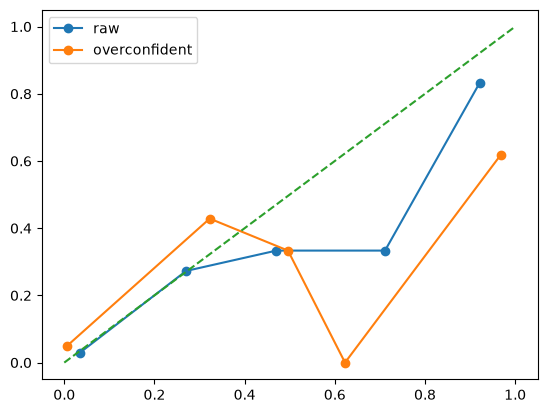

In [2]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score,average_precision_score,brier_score_loss
from sklearn.calibration import calibration_curve
X,y=make_classification(n_samples=800,weights=[.9,.1],random_state=7)
p=LogisticRegression(max_iter=1000).fit(X[:500],y[:500]).predict_proba(X[500:])[:,1]
for name,prob in [("raw",p),("overconfident",p**3/(p**3+(1-p)**3))]:
    print(name,"ROC",roc_auc_score(y[500:],prob),"AP",average_precision_score(y[500:],prob),"Brier",brier_score_loss(y[500:],prob))
    observed,predicted=calibration_curve(y[500:],prob,n_bins=5);plt.plot(predicted,observed,"o-",label=name)
plt.plot([0,1],[0,1],"--");plt.legend();plt.show()

## Expected Observations

The monotone transformation preserves ranking but changes calibration. Average precision is a step-weighted summary, not automatically the same as trapezoidal PR-AUC.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. ROC-AUC summarizes positive-negative ranking. Precision-recall measures emphasize positive retrieval under class imbalance. Calibration asks whether predictions near .7 occur about 70 percent of the time; a ranking metric does not answer that.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. The monotone transformation preserves ranking but changes calibration. Average precision is a step-weighted summary, not automatically the same as trapezoidal PR-AUC.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/pr-auc-roc-auc-calibration.html)
